# 📂 Clase 1 — Lectura y escritura de archivos CSV
## Obtención de datos y fundamentos de Numpy

**Situación:** Eres parte del equipo de análisis comercial de una empresa distribuidora de productos de consumo masivo. Tu jefatura te envió el archivo `ventas_mensuales.csv` con el detalle de ventas del último mes.

Se espera que respondas:
- ¿Qué sucursales tienen mayor volumen de ventas?
- ¿Qué productos están destacando en cada ciudad?
- ¿Cómo preparar esta información para un informe de gerencia?

> ⚠️ El archivo contiene errores intencionales para practicar diagnóstico y limpieza.

---
## 📦 Librerías necesarias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## PASO 1 — Carga del archivo CSV

### 1.1 Lectura básica con `read_csv()`

In [2]:
df = pd.read_csv('01. Apoyo ejercicio - Ventas mensuales.csv')

print('=== Primeras filas del archivo ===')
df.head(5)

=== Primeras filas del archivo ===


,fecha,sucursal,vendedor,producto,categoria,cantidad,precio
0,2024-05-01,Santiago Centro,Carlos Soto,Pan Molde 550g,Panadería,9,862.0
1,2024-05-01,Santiago Centro,Carlos Soto,Aceite Vegetal 1L,Abarrotes,5,2076.0
2,2024-05-01,Santiago Centro,Carlos Soto,Atún en Lata 170g,Conservas,18,1452.0
3,2024-05-02,Santiago Centro,Carlos Soto,Jabón Barra x3,Limpieza,2,1757.0
4,2024-05-02,Santiago Centro,Carlos Soto,Leche Entera 1L,Lácteos,7,959.0


### 1.2 Diagnóstico inicial del DataFrame

In [3]:
print('=== Información general ===')
print(df.info())
print()
print('=== Dimensiones del dataset ===')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print()
print('=== Nombres de columnas ===')
print(df.columns.tolist())

=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      1196 non-null   object 
 1   sucursal   1196 non-null   object 
 2   vendedor   1196 non-null   object 
 3   producto   1196 non-null   object 
 4   categoria  1196 non-null   object 
 5   cantidad   1196 non-null   object 
 6   precio     1195 non-null   float64
dtypes: float64(1), object(6)
memory usage: 65.5+ KB
None

=== Dimensiones del dataset ===
Filas: 1196 | Columnas: 7

=== Nombres de columnas ===
['fecha', 'sucursal', 'vendedor', 'producto', 'categoria', 'cantidad', 'precio']


### ✏️ Ejercicio 1.2 — Responde:

In [4]:
# ✏️ ¿Los nombres de columnas tienen sentido? ¿Hay alguna columna innecesaria?
respuesta_columnas = ""

# ✏️ ¿Qué tipos de datos detectaste en cada columna? ¿Hay algo inesperado?
respuesta_tipos = ""

print(respuesta_columnas)
print(respuesta_tipos)

---
## PASO 2 — Diagnóstico y limpieza de datos

### 2.1 Detectar valores faltantes

In [5]:
print('=== Valores faltantes por columna ===')
print(df.isnull().sum())
print()
print('=== Filas con valores faltantes ===')
print(df[df.isnull().any(axis=1)])

=== Valores faltantes por columna ===
fecha        0
sucursal     0
vendedor     0
producto     0
categoria    0
cantidad     0
precio       1
dtype: int64

=== Filas con valores faltantes ===
         fecha         sucursal     vendedor             producto categoria  \
10  2024-05-03  Santiago Centro  Carlos Soto  Yogurt Natural 500g   Lácteos   

   cantidad  precio  
10        7     NaN  


### 2.2 Detectar inconsistencias en columnas de texto

In [6]:
print('=== Valores únicos en columna sucursal ===')
print(df['sucursal'].unique())
print()
print('=== Valores únicos en columna categoria ===')
print(df['categoria'].unique())

=== Valores únicos en columna sucursal ===
['Santiago Centro' 'santiago centro' 'Valparaíso' 'Concepción' 'La Serena'
 'Antofagasta' 'Temuco' 'Puerto Montt' 'Rancagua']

=== Valores únicos en columna categoria ===
['Panadería' 'Abarrotes' 'Conservas' 'Limpieza' 'Lácteos' 'Bebidas']


### ✏️ Ejercicio 2.2 — Detecta los errores intencionales:

In [7]:
# ✏️ Describe los errores que encontraste:
errores_detectados = """
Error 1 (valor faltante):       
Error 2 (valor no numérico):    
Error 3 (formato de fecha):     
Error 4 (inconsistencia texto): 
"""
print(errores_detectados)


Error 1 (valor faltante):       
Error 2 (valor no numérico):    
Error 3 (formato de fecha):     
Error 4 (inconsistencia texto): 



### 2.3 Corrección de errores

In [8]:
# Paso a) Convertir 'cantidad' a numérico (errors='coerce' transforma no-numéricos a NaN)
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce')

# Paso b) Convertir 'precio' a numérico
df['precio'] = pd.to_numeric(df['precio'], errors='coerce')

# Paso c) Estandarizar nombres de sucursal (capitalizar correctamente)
df['sucursal'] = df['sucursal'].str.title()

# Paso d) Eliminar filas con NaN en columnas críticas
df_limpio = df.dropna(subset=['cantidad', 'precio'])

print(f'Filas originales:  {len(df)}')
print(f'Filas después de limpieza: {len(df_limpio)}')
print(f'Filas eliminadas:  {len(df) - len(df_limpio)}')
print()
print('=== Sucursales únicas (corregidas) ===')
print(df_limpio['sucursal'].unique())

Filas originales:  1196
Filas después de limpieza: 1194
Filas eliminadas:  2

=== Sucursales únicas (corregidas) ===
['Santiago Centro' 'Valparaíso' 'Concepción' 'La Serena' 'Antofagasta'
 'Temuco' 'Puerto Montt' 'Rancagua']


### ✏️ Ejercicio 2.3 — Reflexión:

In [9]:
# ✏️ ¿Por qué usamos errors='coerce' y no errors='raise' en pd.to_numeric()?
respuesta_coerce = ""

# ✏️ ¿Qué alternativa existe a eliminar las filas con NaN? ¿Cuándo usarías cada opción?
respuesta_alternativa = ""

print(respuesta_coerce)
print(respuesta_alternativa)

---
## PASO 3 — Cálculo y análisis

### 3.1 Calcular columna `total_venta`

In [10]:
df_limpio = df_limpio.copy()
df_limpio['total_venta'] = df_limpio['cantidad'] * df_limpio['precio']

print('=== DataFrame con total_venta ===')
print(df_limpio[['fecha','sucursal','producto','cantidad','precio','total_venta']].head(10))

=== DataFrame con total_venta ===
        fecha         sucursal             producto  cantidad  precio  \
0  2024-05-01  Santiago Centro       Pan Molde 550g       9.0   862.0   
1  2024-05-01  Santiago Centro    Aceite Vegetal 1L       5.0  2076.0   
2  2024-05-01  Santiago Centro    Atún en Lata 170g      18.0  1452.0   
3  2024-05-02  Santiago Centro       Jabón Barra x3       2.0  1757.0   
4  2024-05-02  Santiago Centro      Leche Entera 1L       7.0   959.0   
5  2024-05-02  Santiago Centro      Jugo Natural 1L      20.0  1606.0   
6  2024-05-02  Santiago Centro      Jugo Natural 1L       7.0  1739.0   
7  2024-05-02  Santiago Centro       Jabón Barra x3       8.0  1864.0   
8  2024-05-02  Santiago Centro    Agua Mineral 1.5L       9.0   541.0   
9  2024-05-02  Santiago Centro  Yogurt Natural 500g      14.0  1237.0   

   total_venta  
0       7758.0  
1      10380.0  
2      26136.0  
3       3514.0  
4       6713.0  
5      32120.0  
6      12173.0  
7      14912.0  
8       4

### 3.2 Identificar ventas destacadas (total_venta > $10.000)

In [11]:
df_destacadas = df_limpio[df_limpio['total_venta'] > 10000]

print(f'Transacciones destacadas: {len(df_destacadas)} de {len(df_limpio)}')
print()
print('=== Productos más frecuentes en ventas destacadas ===')
print(df_destacadas['producto'].value_counts().head(8))

Transacciones destacadas: 700 de 1194

=== Productos más frecuentes en ventas destacadas ===
producto
Atún en Lata 170g        83
Jabón Barra x3           81
Jugo Natural 1L          78
Detergente 1kg           78
Aceite Vegetal 1L        73
Yogurt Natural 500g      61
Arroz Grano Largo 1kg    58
Leche Entera 1L          55
Name: count, dtype: int64


### ✏️ Ejercicio 3.2 — Analiza:

In [12]:
# ✏️ ¿Son los productos destacados de alto precio o de alta cantidad?
# Investiga usando las columnas cantidad y precio:
print('=== Estadísticas de ventas destacadas ===')
print(df_destacadas[['cantidad','precio','total_venta']].describe())

# ✏️ Escribe tu conclusión:
conclusion_destacadas = ""
print('\nConclusión:', conclusion_destacadas)

=== Estadísticas de ventas destacadas ===
         cantidad       precio   total_venta
count  700.000000   700.000000    700.000000
mean    14.017143  1605.180000  21671.092857
std      4.150908   712.322492  11269.553317
min      4.000000   542.000000  10002.000000
25%     11.000000  1013.250000  13555.000000
50%     14.000000  1504.000000  18544.500000
75%     18.000000  1864.000000  26166.500000
max     20.000000  3294.000000  65880.000000

Conclusión: 


---
## PASO 4 — Agrupación y exportación

### 4.1 Agrupar por sucursal

In [13]:
ventas_por_sucursal = df_limpio.groupby('sucursal')['total_venta'].sum().sort_values(ascending=False)

print('=== Total de ventas por sucursal ===')
for sucursal, total in ventas_por_sucursal.items():
    print(f'  {sucursal:<20} ${total:>12,.0f}')

=== Total de ventas por sucursal ===
  La Serena            $   2,434,767
  Valparaíso           $   2,345,750
  Puerto Montt         $   2,291,327
  Temuco               $   2,281,112
  Antofagasta          $   2,251,816
  Concepción           $   2,181,083
  Santiago Centro      $   2,109,449
  Rancagua             $   1,961,734


### 4.2 Agrupar por producto y categoría

In [14]:
ventas_por_producto = (
    df_limpio.groupby(['producto','categoria'])
    .agg(unidades_vendidas=('cantidad','sum'), total_ventas=('total_venta','sum'))
    .sort_values('total_ventas', ascending=False)
    .reset_index()
)

print('=== Top 10 productos por ventas totales ===')
print(ventas_por_producto.head(10).to_string(index=False))

=== Top 10 productos por ventas totales ===
             producto categoria  unidades_vendidas  total_ventas
       Detergente 1kg  Limpieza             1004.0     3241215.0
       Jabón Barra x3  Limpieza             1183.0     2162178.0
    Aceite Vegetal 1L Abarrotes              958.0     2037049.0
    Atún en Lata 170g Conservas             1247.0     1876424.0
      Jugo Natural 1L   Bebidas             1081.0     1804816.0
Arroz Grano Largo 1kg Abarrotes              976.0     1338713.0
  Yogurt Natural 500g   Lácteos             1025.0     1258228.0
      Leche Entera 1L   Lácteos             1137.0     1110507.0
  Tomate en Lata 400g Conservas              968.0      817946.0
       Pan Molde 550g Panadería              892.0      783476.0


### 4.3 Visualización

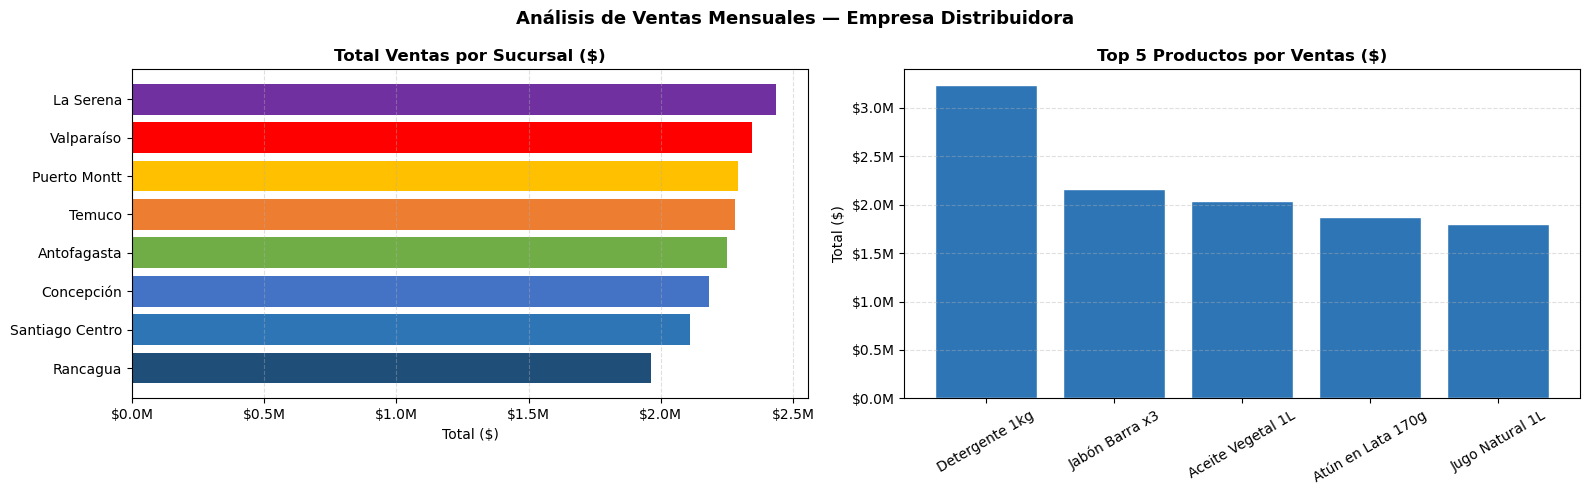

✅ Gráfico guardado como ventas_grafico.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análisis de Ventas Mensuales — Empresa Distribuidora', fontsize=13, fontweight='bold')

# Gráfico 1: Ventas por sucursal
colores = ['#1F4E79','#2E75B6','#4472C4','#70AD47','#ED7D31','#FFC000','#FF0000','#7030A0']
axes[0].barh(ventas_por_sucursal.index[::-1], ventas_por_sucursal.values[::-1], color=colores)
axes[0].set_title('Total Ventas por Sucursal ($)', fontweight='bold')
axes[0].set_xlabel('Total ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# Gráfico 2: Top 5 productos
top5 = ventas_por_producto.head(5)
axes[1].bar(top5['producto'], top5['total_ventas'], color='#2E75B6', edgecolor='white')
axes[1].set_title('Top 5 Productos por Ventas ($)', fontweight='bold')
axes[1].set_ylabel('Total ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('ventas_grafico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado como ventas_grafico.png')

### 4.4 Exportar archivos CSV con `to_csv()`

In [16]:
# Archivo 1: Resumen por sucursal (para gerencia)
ventas_por_sucursal.to_csv('ventas_resumen.csv', sep=';', header=True)
print('✅ ventas_resumen.csv generado')

# Archivo 2: Solo ventas destacadas
df_destacadas[['fecha','sucursal','producto','cantidad','precio','total_venta']].to_csv(
    'ventas_destacadas.csv', sep=';', index=False, float_format='%.0f'
)
print('✅ ventas_destacadas.csv generado')

# Archivo 3: Resumen completo para Power BI (sin índice, con punto y coma)
df_limpio.to_csv('ventas_completo_limpio.csv', sep=';', index=False, 
                  float_format='%.0f', encoding='utf-8')
print('✅ ventas_completo_limpio.csv generado')

✅ ventas_resumen.csv generado
✅ ventas_destacadas.csv generado
✅ ventas_completo_limpio.csv generado


### 4.5 Verificar los archivos generados

In [17]:
print('=== Verificación: ventas_resumen.csv ===')
verificado = pd.read_csv('ventas_resumen.csv', sep=';')
print(verificado)
print()
print('=== Verificación: ventas_destacadas.csv (primeras 5 filas) ===')
verificado2 = pd.read_csv('ventas_destacadas.csv', sep=';')
print(verificado2.head())
print(f'Total filas: {len(verificado2)}')

=== Verificación: ventas_resumen.csv ===
          sucursal  total_venta
0        La Serena    2434767.0
1       Valparaíso    2345750.0
2     Puerto Montt    2291327.0
3           Temuco    2281112.0
4      Antofagasta    2251816.0
5       Concepción    2181083.0
6  Santiago Centro    2109449.0
7         Rancagua    1961734.0

=== Verificación: ventas_destacadas.csv (primeras 5 filas) ===
        fecha         sucursal           producto  cantidad  precio  \
0  2024-05-01  Santiago Centro  Aceite Vegetal 1L         5    2076   
1  2024-05-01  Santiago Centro  Atún en Lata 170g        18    1452   
2  2024-05-02  Santiago Centro    Jugo Natural 1L        20    1606   
3  2024-05-02  Santiago Centro    Jugo Natural 1L         7    1739   
4  2024-05-02  Santiago Centro     Jabón Barra x3         8    1864   

   total_venta  
0        10380  
1        26136  
2        32120  
3        12173  
4        14912  
Total filas: 700


---
## PASO 5 — Preguntas de reflexión

### ✏️ Responde las preguntas de cierre del ejercicio:

In [18]:
# ✏️ 1. ¿Qué decisiones podría tomar la gerencia a partir del archivo ventas_resumen.csv?
decision_gerencia = ""

# ✏️ 2. ¿Qué limitaciones ves en este análisis si solo usamos CSV y no bases de datos?
limitaciones = ""

# ✏️ 3. ¿Cómo podrías automatizar este proceso para ejecutarlo cada mes?
automatizacion = ""

print('--- REFLEXIONES ---')
print(f'1. Decisiones de gerencia:  {decision_gerencia}')
print(f'2. Limitaciones del CSV:    {limitaciones}')
print(f'3. Automatización mensual:  {automatizacion}')

--- REFLEXIONES ---
1. Decisiones de gerencia:  
2. Limitaciones del CSV:    
3. Automatización mensual:  


---
## PASO 6 — Desafío extra: leer un CSV desde URL

Pandas puede leer archivos CSV directamente desde internet. Practica con datos públicos:

In [19]:
# ✏️ Desafío: lee el siguiente CSV público y muestra las primeras 5 filas
url = 'https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv'

# df_url = pd.read_csv(url)
# print(df_url.head())
# print(df_url.info())

# ✏️ ¿Cuántas filas y columnas tiene?
# ✏️ ¿Qué tipo de datos contiene?
print('Descomenta las líneas de arriba para ejecutar el desafío.')

Descomenta las líneas de arriba para ejecutar el desafío.


---
## 📋 Resumen de parámetros clave

| Función | Parámetro | Uso |
|---------|-----------|-----|
| `read_csv()` | `sep=';'` | Separador punto y coma (Chile/Europa) |
| `read_csv()` | `encoding='utf-8'` | Tildes y ñ correctas |
| `read_csv()` | `header=None` | Archivo sin cabecera |
| `read_csv()` | `skiprows=2` | Saltar filas iniciales |
| `read_csv()` | `usecols=['col1','col2']` | Cargar solo columnas específicas |
| `to_csv()` | `index=False` | No escribir el índice |
| `to_csv()` | `sep=';'` | Separador punto y coma |
| `to_csv()` | `float_format='%.2f'` | Dos decimales |
| `to_csv()` | `date_format='%Y-%m-%d'` | Formato de fecha ISO |

> 💡 **Regla de oro:** Antes de procesar un CSV, ábrelo con un editor de texto para identificar visualmente el separador, la codificación y si tiene cabecera.